In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib

In [2]:
import sys
sys.path.append('../data_preprocessing')

In [3]:
import feature_engineering_scaling as fes 

2025-03-21 11:10:45.395545: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-21 11:10:45.516913: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-21 11:10:48.197189: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


DECISION TREE MODEL

In [4]:
# Define a function to train and evaluate a decision tree
def train_and_evaluate_decision_tree(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize the Decision Tree Classifier
    model = DecisionTreeClassifier(random_state=0)
    
    # Train the model on the training data
    model.fit(X_train, y_train)
    
    # Evaluate on validation set
    y_val_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    print("Validation Accuracy:", val_accuracy)
    print("Validation Classification Report:")
    print(classification_report(y_val, y_val_pred))
    
    # Evaluate on test set
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print("Test Accuracy:", test_accuracy)
    print("Test Classification Report:")
    print(classification_report(y_test, y_test_pred))
    
    return model


In [5]:
X = fes.X_scaled
y = fes.y

In [6]:
scaler = MinMaxScaler()
X.loc[:, 'time'] = scaler.fit_transform(X[['time']])

In [7]:
#Since the truth need not be one hot encoded for decision tree, spliting of the dataset is done here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

In [8]:
# Model
print("Training and evaluating Decision Tree")
model_dt_1 = train_and_evaluate_decision_tree(X_train, y_train, X_val, y_val, X_test, y_test)

Training and evaluating Decision Tree
Validation Accuracy: 0.6076957102919236
Validation Classification Report:


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         0.0       0.73      0.75      0.74    173141
         1.0       0.39      0.40      0.39    172588
         2.0       0.79      0.77      0.78    173395
         3.0       0.60      0.60      0.60    171981
         4.0       0.37      0.38      0.37    169590
         5.0       0.77      0.75      0.76    170190
         9.0       0.00      0.00      0.00         1

    accuracy                           0.61   1030886
   macro avg       0.52      0.52      0.52   1030886
weighted avg       0.61      0.61      0.61   1030886

Test Accuracy: 0.6066923429719069
Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.75      0.74    215377
         1.0       0.39      0.39      0.39    217573
         2.0       0.79      0.77      0.78    216543
         3.0       0.60      0.60      0.60    215634
         4.0       0.37      0.38      0.37    211648
         5.0    

GRID SEARCH

In [9]:
# Now to fnd the best hyperparameters for the best model, define the GridSearch function
def perform_grid_search(X_train, y_train, param_grid):
    # Initialize the Decision Tree model
    dt = DecisionTreeClassifier(random_state=0)
    
    # Set up GridSearchCV with cross-validation
    grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
    
    # Perform the grid search on the training data
    grid_search.fit(X_train, y_train)
    
    # Output the best parameters and best score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Cross-Validation Accuracy:", grid_search.best_score_)
    
    return grid_search.best_estimator_

In [10]:
# Define the hyperparameter grid for Grid Search
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}

# Grid Search

In [11]:
# Perform Grid Search 
print("Performing Grid Search")
best_dt_model = perform_grid_search(X_train, y_train, param_grid)

Performing Grid Search
Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time= 3.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time= 3.2min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time= 3.4min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time= 3.5min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time= 2.8min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time= 3.2min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time= 2.9min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time= 3.1min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time= 3.1min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time= 3.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=

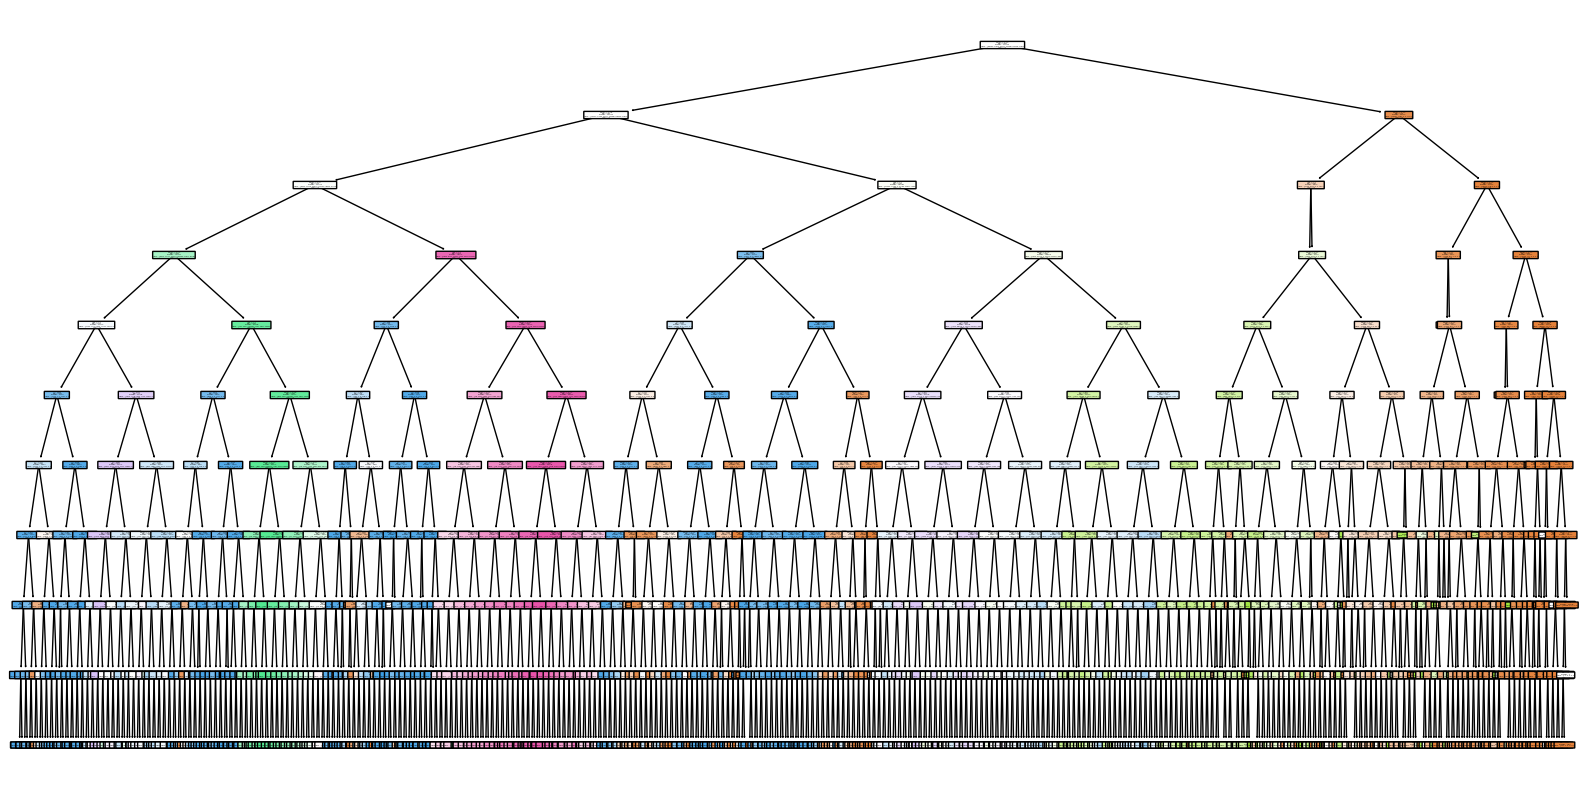

In [12]:
# Ensure feature names
feature_names = X.columns if isinstance(X, pd.DataFrame) else ["Feature_" + str(i) for i in range(X.shape[1])]

# Ensure class names
class_names = [str(cls) for cls in np.unique(y)]

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True
)
plt.show()

In [13]:
# Save the model to a file
joblib.dump(best_dt_model, '../models/model_decision_tree_whole.pkl')

['../models/model_decision_tree_whole.pkl']